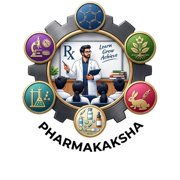

# BP201T · Unit V — Statistical Analysis Using Python
**Pharmakaksha · Learn · Grow · Achieve**
*Applied Biostatistics and Data Analytics for Pharmaceutical Sciences · B.Pharm Semester II · PCI NEP 2020*

This notebook contains every example and demo from the Unit V study notes, slides and video, in the same order.

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ajreddys/learn-pharmakaksha-site/blob/main/content/BP201T%20Applied%20Biostatistics%20and%20Data%20Analytics%20for%20Pharmaceutical%20Sciences%20%28Theory%29/BP201T_Unit5_Statistical_Analysis_Case_Studies.ipynb)

**How to use this notebook**
1. Open it at [learn.pharmakaksha.com](https://learn.pharmakaksha.com/notebooks/index.html?path=BP201T%20Applied%20Biostatistics%20and%20Data%20Analytics%20for%20Pharmaceutical%20Sciences%20%28Theory%29/BP201T_Unit5_Statistical_Analysis_Case_Studies.ipynb) (no login needed) or in **Google Colab** with the button above (sign in with Google; use **File → Save a copy in Drive** to keep your work).
2. Click a code cell and press **Shift + Enter** to run it. Run the cells from top to bottom.
3. The practice datasets sit next to this notebook. In Colab they are read from GitHub automatically.

**Using learn.pharmakaksha.com**
Python runs inside your web browser, so nothing is installed and nothing is sent to a server. Use an up-to-date Chrome, Edge, Firefox or Safari, on a laptop or a phone.
- **The first run is slow.** The first time you run a cell, the browser downloads Python, which can take 10–30 seconds. The first `import statsmodels` takes a few seconds more. After that, cells run quickly.
- **Check the kernel.** *Python (Pyodide)* appears at the top right. A filled circle means Python is busy, and an empty circle means it is ready.
- **If a cell hangs** or you want a fresh start, use **Kernel → Restart Kernel**, then run the cells from the top again.
- **Save your work.** Press **Ctrl + S** (**Cmd + S** on a Mac). Your work is saved in this browser only. It will not appear on another device, and clearing your browsing data or using a private/incognito window erases it. Use **File → Download** to keep a copy.
- **Start over.** The site keeps opening your saved copy of the notebook. To get the original version back, go to the file list, tick the notebook, click **Delete** and reload the page.

> All datasets are fictional teaching data. The analyses are for learning statistics only. They are not clinical or regulatory decisions.

## 5.1 The analysis workflow and the three libraries
Every statistical analysis follows the same path: **question → data → describe → test or model → interpret → report**.

| Library | Best for | Typical call |
|---|---|---|
| **SciPy** (`scipy.stats`) | Quick tests and simple regression | `ttest_ind`, `pearsonr`, `linregress` |
| **Statsmodels** | Full statistical models with p-values and CIs | `smf.ols("y ~ x", data).fit().summary()` |
| **scikit-learn** | Prediction and machine learning (BP301T) | `LinearRegression().fit(X, y)` |

This cell loads all three.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

URL = "https://raw.githubusercontent.com/ajreddys/learn-pharmakaksha-site/main/content/BP201T%20Applied%20Biostatistics%20and%20Data%20Analytics%20for%20Pharmaceutical%20Sciences%20%28Theory%29/"

def load(name):
    """Read a practice CSV from this folder, or from GitHub (Colab)."""
    if os.path.exists(name):
        return pd.read_csv(name)
    return pd.read_csv(URL + name)

In [ ]:
from scipy import stats
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression
import statsmodels, scipy, sklearn
print("SciPy", scipy.__version__, "| statsmodels", statsmodels.__version__, "| scikit-learn", sklearn.__version__)

## Case study 1: an antihypertensive trial
**Question:** In the 8-week trial of 120 patients (`bp_trial.csv`), does the drug lower systolic blood pressure more than placebo, and by how much?

### 5.2 Step 1: describe the data

In [ ]:
bp = load("bp_trial.csv")
print(bp.shape, "| missing values:", bp.isna().sum().sum())

table1 = bp.groupby("group").agg(
    n=("patient_id", "count"), age=("age", "mean"), male_pct=("sex", lambda s: 100 * (s == "M").mean()),
    baseline_sbp=("baseline_sbp", "mean"), week8_sbp=("week8_sbp", "mean"),
    sbp_drop=("sbp_drop", "mean"), sbp_drop_sd=("sbp_drop", "std")).round(1)
table1

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
groups = ["Drug", "Placebo"]
data = [bp[bp.group == g]["sbp_drop"] for g in groups]
ax[0].boxplot(data, widths=0.5, patch_artist=True, boxprops=dict(facecolor="#DFF3EC", color="#12303A"),
              medianprops=dict(color="#E07A2E", linewidth=2))
ax[0].set_xticks([1, 2], groups); ax[0].set_ylabel("Fall in SBP at week 8 (mmHg)")
ax[0].set_title("Fall in SBP by group"); ax[0].axhline(0, color="grey", linestyle=":")
for g, c in zip(groups, ["#17725C", "#E07A2E"]):
    s = bp[bp.group == g]
    ax[1].scatter(s["baseline_sbp"], s["sbp_drop"], color=c, alpha=0.75, label=g)
ax[1].set_xlabel("Baseline SBP (mmHg)"); ax[1].set_ylabel("Fall in SBP (mmHg)")
ax[1].set_title("Higher baseline, bigger fall"); ax[1].legend()
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 5.3 Step 2: test the difference (SciPy)
Before a t-test, check that each group is roughly normal. The **Shapiro–Wilk** test has H₀: the data are normal, so p > 0.05 is reassuring.

In [ ]:
drug = bp[bp.group == "Drug"]["sbp_drop"]; placebo = bp[bp.group == "Placebo"]["sbp_drop"]
print("Shapiro-Wilk p: drug", round(stats.shapiro(drug).pvalue, 3), "| placebo", round(stats.shapiro(placebo).pvalue, 3))

res = stats.ttest_ind(drug, placebo, equal_var=False)
ci = res.confidence_interval()
print(f"Difference {drug.mean() - placebo.mean():.2f} mmHg, 95% CI {ci.low:.2f} to {ci.high:.2f}, t = {res.statistic:.2f}, p = {res.pvalue:.1e}")

### 5.4 Step 3: correlation
`DataFrame.corr()` gives every pairwise Pearson r at once (a **correlation matrix**).

In [ ]:
cols = ["age", "bmi", "baseline_sbp", "sbp_drop"]
print(bp[cols].corr().round(2))
r, p = stats.pearsonr(bp["baseline_sbp"], bp["sbp_drop"])
print(f"\nBaseline SBP vs fall: r = {r:.2f}, p = {p:.4f}")

### 5.5 Step 4: linear regression three ways
**(a) SciPy `linregress`**: one predictor only.

In [ ]:
f = stats.linregress(bp["baseline_sbp"], bp["sbp_drop"])
print(f"sbp_drop = {f.intercept:.2f} + {f.slope:.3f} × baseline_sbp   R² = {f.rvalue ** 2:.3f}, p = {f.pvalue:.4f}")

**(b) Statsmodels OLS** with a formula. `C(group)` turns the text column into a 0/1 indicator, so one model estimates the **drug effect adjusted for baseline SBP**.

In [ ]:
model = smf.ols("sbp_drop ~ C(group, Treatment('Placebo')) + baseline_sbp", data=bp).fit()
print(model.summary())

**How to read the summary**

| Part of the output | What it tells you |
|---|---|
| `coef` | The estimated effect. Drug row: extra fall in SBP vs placebo, at the same baseline. `baseline_sbp`: extra fall per 1 mmHg higher baseline |
| `std err` | Uncertainty of the coefficient |
| `t` and `P>|t|` | Test of H₀: coefficient = 0. p < 0.05 = a real effect |
| `[0.025  0.975]` | 95% confidence interval of the coefficient |
| `R-squared`, `Adj. R-squared` | Share of variation explained (adjusted penalises extra predictors) |
| `F-statistic`, `Prob (F-statistic)` | Does the model as a whole explain anything? |
| `No. Observations` | Rows used: check nothing was dropped |

In [ ]:
print("Coefficients:\n", model.params.round(3))
print("\np-values:\n", model.pvalues.apply(lambda v: f"{v:.2e}"))
print("\n95% CI:\n", model.conf_int().round(2))
print("\nR² =", round(model.rsquared, 3), " adjusted R² =", round(model.rsquared_adj, 3), " n =", int(model.nobs))

**(c) scikit-learn**: the same coefficients, but no p-values or CIs. scikit-learn is built for **prediction**; Statsmodels is built for **inference** (testing and explaining).

In [ ]:
X = pd.DataFrame({"drug": (bp["group"] == "Drug").astype(int), "baseline_sbp": bp["baseline_sbp"]})
sk = LinearRegression().fit(X, bp["sbp_drop"])
print("Intercept:", round(sk.intercept_, 3))
print("Coefficients:", dict(zip(X.columns, sk.coef_.round(3))))
print("R²:", round(sk.score(X, bp["sbp_drop"]), 3))
print("Predicted fall, drug patient with baseline 170:", round(sk.predict(pd.DataFrame({"drug": [1], "baseline_sbp": [170]}))[0], 1), "mmHg")

### 5.6 Step 5: check the model
Residuals should be centred on zero with no pattern, and roughly normal.

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].scatter(model.fittedvalues, model.resid, color="#12303A", alpha=0.7)
ax[0].axhline(0, color="#E07A2E"); ax[0].set_xlabel("Fitted value (mmHg)"); ax[0].set_ylabel("Residual (mmHg)")
ax[0].set_title("Residuals vs fitted: no pattern")
ax[1].hist(model.resid, bins=15, color="#1F8A70", edgecolor="white")
ax[1].set_xlabel("Residual (mmHg)"); ax[1].set_title("Residuals: roughly normal")
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Shapiro-Wilk p for residuals:", round(stats.shapiro(model.resid).pvalue, 3))

## Case study 2: shelf life from stability data
**Question:** Three batches of a tablet were stored at 25 °C / 60% RH and assayed at 0, 3, 6, 9, 12 and 18 months (`stability.csv`). The specification is **not less than 95.0%** of label claim. What shelf life does the data support?

Following the ICH Q1E approach, the shelf life is the time at which the **lower one-sided 95% confidence limit** of the mean regression line meets the specification. (A one-sided 95% limit equals the lower end of a two-sided 90% interval.)

In [ ]:
st = load("stability.csv")
print(st.pivot(index="month", columns="batch", values="assay_pct"))

stab = smf.ols("assay_pct ~ month", data=st).fit()
print(f"\nassay = {stab.params['Intercept']:.2f} + ({stab.params['month']:.4f}) × month,  R² = {stab.rsquared:.3f}, p = {stab.pvalues['month']:.1e}")

In [ ]:
months = pd.DataFrame({"month": np.arange(0, 49, 0.25)})
band = stab.get_prediction(months).summary_frame(alpha=0.10)      # 90% two-sided = 95% one-sided
lower = band["mean_ci_lower"]
shelf = months["month"][lower < 95.0].iloc[0]
print(f"Lower 95% confidence limit reaches 95.0% at about {shelf:.1f} months")
print(f"Point estimate reaches 95.0% at {(95 - stab.params['Intercept']) / stab.params['month']:.1f} months")

plt.figure(figsize=(9, 5))
for bt, c in zip(["B1", "B2", "B3"], ["#17725C", "#1F8A70", "#12303A"]):
    s = st[st.batch == bt]; plt.scatter(s["month"], s["assay_pct"], color=c, label=f"Batch {bt}")
plt.plot(months["month"], band["mean"], color="#E07A2E", linewidth=2, label="Regression line")
plt.plot(months["month"], lower, color="#E07A2E", linestyle="--", label="Lower 95% confidence limit")
plt.axhline(95, color="#12303A", linestyle=":", label="Specification 95.0%")
plt.axvline(shelf, color="grey", linestyle=":")
plt.text(shelf + 0.5, 99.5, f"{shelf:.1f} months")
plt.xlabel("Months at 25 °C / 60% RH"); plt.ylabel("Assay (% of label claim)")
plt.title("Shelf-life estimation by regression"); plt.legend(loc="lower left"); plt.grid(alpha=0.3); plt.show()

The lower confidence limit crosses 95.0% at about 25.8 months, so the data support a proposed shelf life of **24 months** (shelf lives are rounded down). ICH Q1E limits how far beyond the real data you may extrapolate: for room-temperature storage, generally up to twice the period covered and not more than 12 months beyond it. With 18 months of data, 24 months is within that limit, and the company must confirm it with real-time data later.

## 5.7 Writing a statistical report
A good report lets a reader repeat the analysis and trust the conclusion. Use this structure:

1. **Objective:** the question, in one sentence.
2. **Data:** source, sample size, variables, missing values.
3. **Methods:** the tests and models, α = 0.05, the software (Python 3, SciPy, Statsmodels).
4. **Results:** descriptive statistics (mean ± SD, n), the effect estimate **with its 95% CI and p-value**, tables and figures.
5. **Interpretation:** what it means clinically, not just statistically.
6. **Limitations:** sample size, bias, assumptions checked or not.

Python can write the results section straight from the numbers, so the report never disagrees with the analysis:

In [ ]:
eff = model.params.iloc[1]; lo, hi = model.conf_int().iloc[1]
report = f"""RESULTS
{int(model.nobs)} patients were analysed ({(bp.group == 'Drug').sum()} drug, {(bp.group == 'Placebo').sum()} placebo); no data were missing.
Mean fall in SBP at week 8 was {drug.mean():.1f} ± {drug.std():.1f} mmHg on drug and {placebo.mean():.1f} ± {placebo.std():.1f} mmHg on placebo
(Welch t = {res.statistic:.2f}, p < 0.001).
Adjusted for baseline SBP, the drug lowered SBP by {eff:.1f} mmHg more than placebo (95% CI {lo:.1f} to {hi:.1f}; p < 0.001).
Each 10 mmHg higher baseline SBP was associated with a {10 * model.params['baseline_sbp']:.1f} mmHg larger fall. The model explained {100 * model.rsquared:.0f}% of the variation (R²).
Stability: assay fell by {abs(stab.params['month']):.2f}% per month; the lower 95% confidence limit reached 95.0% at {shelf:.1f} months."""
print(report)

## Quick check
In a Statsmodels summary, a coefficient has `coef = 2.1`, `P>|t| = 0.41` and CI `[-3.0, 7.2]`. Is the effect significant? Decide, then run the cell.

In [ ]:
print("No: p = 0.41 > 0.05 and the 95% CI includes 0. The data are compatible with no effect.")

## Try it yourself (lab)
**1.** Add `age` to the trial model (`sbp_drop ~ C(group, Treatment('Placebo')) + baseline_sbp + age`). Is age a significant predictor?

**2.** Using `dose_response.csv`, fit `sbp_fall_mmHg ~ dose_mg` with Statsmodels and read the slope, its 95% CI and R². Do they match Unit IV?

**3.** Fit the stability model for batch B2 alone. What shelf life does it support?

**4.** Write a three-sentence report of the dose–response analysis using an f-string.

---
## Solutions

In [ ]:
# 1
m2 = smf.ols("sbp_drop ~ C(group, Treatment('Placebo')) + baseline_sbp + age", data=bp).fit()
print(m2.params.round(3)); print(m2.pvalues.round(3))   # age p > 0.05: not significant

In [ ]:
# 2
dr = load("dose_response.csv")
m3 = smf.ols("sbp_fall_mmHg ~ dose_mg", data=dr).fit()
print(m3.params.round(3)); print(m3.conf_int().round(3)); print(round(m3.rsquared, 3))

In [ ]:
# 3
b2 = smf.ols("assay_pct ~ month", data=st[st.batch == "B2"]).fit()
low = b2.get_prediction(months).summary_frame(alpha=0.10)["mean_ci_lower"]
print(months["month"][low < 95].iloc[0], "months")

In [ ]:
# 4
print(f"In {len(dr)} patients, the fall in SBP rose by {m3.params['dose_mg']:.2f} mmHg per mg "
      f"(95% CI {m3.conf_int().loc['dose_mg', 0]:.2f} to {m3.conf_int().loc['dose_mg', 1]:.2f}; p < 0.001). "
      f"Dose explained {100 * m3.rsquared:.0f}% of the variation. The relationship was linear over 10–60 mg.")

---
**Course complete.** Next semester: BP301T Introduction to Machine Learning in Pharmaceutical Sciences. Pharmakaksha · Learn · Grow · Achieve